# Project 2 MLFI



In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.svm import SVC
import matplotlib.pyplot as plt
np.random.seed(0)  

1) a) Compute the empirical means and standard deviations of $x_{i1}$, $x_{i2}$ and $x_{i3}$ over i = 1, . . . , m.

In [2]:

m = 20000  # training samples
n = 10000  # test samples
total_samples = m + n

x1 = np.random.uniform(18, 80, total_samples)
x2 = np.random.uniform(1, 15, total_samples)
x3 = np.random.binomial(1, 0.1, total_samples)


X = np.column_stack((x1, x2, x3))

X_train = X[:m]
X_test = X[m:]

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")


print("\nEmpirical statistics over training data:")
print(f"x1 (age): mean = {np.mean(X_train[:, 0]):.2f}, std = {np.std(X_train[:, 0]):.2f}")
print(f"x2 (income): mean = {np.mean(X_train[:, 1]):.2f}, std = {np.std(X_train[:, 1]):.2f}")
print(f"x3 (employment): mean = {np.mean(X_train[:, 2]):.2f}, std = {np.std(X_train[:, 2]):.2f}")


Training data shape: (20000, 3)
Test data shape: (10000, 3)

Empirical statistics over training data:
x1 (age): mean = 48.74, std = 18.01
x2 (income): mean = 7.99, std = 4.03
x3 (employment): mean = 0.10, std = 0.30


1) b) Can you think of additional features (besides age, income, salaried/self-employed) that could be
relevant in reality?


Additional relevant features for credit risk assessment could include:
1. Credit history: Number of previous loans, payment history, default history
2. Debt-to-income ratio: Existing debt obligations relative to monthly income
3. Collateral value: Value of assets that can secure the loan (house, car, etc.)
4. Geographical features (origin,...)

2) a) Fit a logistic regression model $\hat{p}^{\log}_s : \mathbb{R}^3 \rightarrow (0,1)$ on the training data $(x_i, y^{(s)}_i)$, $i = 1, \ldots, m$.  
Calculate the cross-entropy loss of $\hat{p}^{\log}_s$ on the training and test data. You can use the function sklearn.linear_model.LogisticRegression for this.

In [3]:
sigmoid = lambda x: 1. / (1. + np.exp(-x))

xi = np.random.uniform(0, 1, total_samples)


def p1(x):
    return sigmoid(13.3 - 0.33*x[:, 0] + 3.5*x[:, 1] - 3*x[:, 2])

def p2(x):
    young = (x[:, 0] < 25).astype(float)
    old   = (x[:, 0] > 75).astype(float)
    return sigmoid(5 - 10*(young + old) + 1.1*x[:, 1] - x[:, 2])


prob1 = p1(X)
y1 = (xi <= prob1).astype(int)  # y_i^(1) = 1 if ξ_i ≤ p1(xi), 0 otherwise


X1_train, y1_train = X_train, y1[:m]
X1_test, y1_test = X_test, y1[m:]

  
prob2 = p2(X)
y2 = (xi <= prob2).astype(int)  # y_i^(2) = 1 if ξ_i ≤ p2(xi), 0 otherwise


X2_train, y2_train = X_train, y2[:m]
X2_test, y2_test = X_test, y2[m:]

print("Dataset 1:")
print(f"Training: {np.sum(y1_train)} good borrowers out of {len(y1_train)} ({100*np.mean(y1_train):.1f}%)")
print(f"Test: {np.sum(y1_test)} good borrowers out of {len(y1_test)} ({100*np.mean(y1_test):.1f}%)")
print(f"Average probability p1: {np.mean(prob1[:m]):.3f}")

print("\nDataset 2:")
print(f"Training: {np.sum(y2_train)} good borrowers out of {len(y2_train)} ({100*np.mean(y2_train):.1f}%)")
print(f"Test: {np.sum(y2_test)} good borrowers out of {len(y2_test)} ({100*np.mean(y2_test):.1f}%)")
print(f"Average probability p2: {np.mean(prob2[:m]):.3f}")

Dataset 1:
Training: 19030 good borrowers out of 20000 (95.2%)
Test: 9523 good borrowers out of 10000 (95.2%)
Average probability p1: 0.950

Dataset 2:
Training: 18964 good borrowers out of 20000 (94.8%)
Test: 9513 good borrowers out of 10000 (95.1%)
Average probability p2: 0.948


In [4]:
print("Fitting logistic regression models")


model1 = LogisticRegression(random_state=0, max_iter=1000).fit(X1_train, y1_train)
print(f"Dataset 1 - Model coefficients: {model1.coef_[0]}")
print(f"Dataset 1 - Model intercept: {model1.intercept_[0]}")

 
model2 = LogisticRegression(random_state=0, max_iter=1000).fit(X2_train, y2_train)
print(f"Dataset 2 - Model coefficients: {model2.coef_[0]}")
print(f"Dataset 2 - Model intercept: {model2.intercept_[0]}")


print("\nCross-entropy losses:")


pred1_train = model1.predict_proba(X1_train)
pred1_test = model1.predict_proba(X1_test)


pred2_train = model2.predict_proba(X2_train)
pred2_test = model2.predict_proba(X2_test)


loss1_train = log_loss(y1_train, pred1_train)
loss1_test = log_loss(y1_test, pred1_test)
loss2_train = log_loss(y2_train, pred2_train)
loss2_test = log_loss(y2_test, pred2_test)

print(f"Dataset 1 - Train loss: {loss1_train:.4f}")
print(f"Dataset 1 - Test loss: {loss1_test:.4f}")
print(f"Dataset 2 - Train loss: {loss2_train:.4f}")
print(f"Dataset 2 - Test loss: {loss2_test:.4f}")

Fitting logistic regression models
Dataset 1 - Model coefficients: [-0.3364056   3.43315857 -2.85221731]
Dataset 1 - Model intercept: 14.040139295921964
Dataset 2 - Model coefficients: [ 0.01524858  0.50713716 -0.34719022]
Dataset 2 - Model intercept: -0.3738414420081886

Cross-entropy losses:
Dataset 1 - Train loss: 0.0297
Dataset 1 - Test loss: 0.0349
Dataset 2 - Train loss: 0.1535
Dataset 2 - Test loss: 0.1486


Analysis of Logistic Regression Results:

Dataset 1 - Excellent fit (linear relationship):
- Estimated coefficients: [-0.336, 3.433, -2.852] are close to theoretical ones: [-0.33, 3.5, -3.0]
- Estimated intercept: 14.04 is close to theoretical one: 13.3 (6% relative difference)
- Cross-entropy loss: ~0.03 (very low) → excellent fit

Dataset 2 - Limited fit (non-linear relationship):
- Age coefficient: 0.015 (almost zero) → linear regression cannot capture the non-linear effect of young (<25) and elderly (>75) individuals
- Income coefficient: 0.507 vs theoretical: 1.1 (54% relative difference which is considerable)
- Cross-entropy loss: ~0.15 (5x higher) → poorer fit

Conclusion: Logistic regression works perfectly for linear relationships (Dataset 1) but fails to capture non-linearities (Dataset 2). SVM models with RBF kernel should improve performance on Dataset 2.

## 2) b) 
i) Fit a SVM $\hat{f}^{\mathrm{svm}}_s : \mathbb{R}^3 \rightarrow \mathbb{R}$ of the form

$$
\hat{f}^{\mathrm{svm}}_s(x) = \langle w, \phi(x) \rangle + b
$$
with feature map $\phi$ on the training data using the hinge loss, kernel
$
k(x, x') = \exp\!\left(-\frac{1}{10} \|x - x'\|_2^2\right)
$
and regularization parameter $\lambda = \frac{5}{2m}$.  
You can use the function $\texttt{sklearn.svm.SVC}$ for this (the given choice of $\lambda$ corresponds to the parameter $C = \frac{1}{2\lambda m} = 0.2$ in $\texttt{sklearn.svm.SVC}$).

ii) On top of $\hat{f}^{\mathrm{svm}}_s$, fit a logistic function $\hat{g}_s : \mathbb{R} \rightarrow (0,1)$ of the form
$\hat{g}_s(z) = \frac{1}{1 + \exp(\beta z + \gamma)}$
for parameters $\beta, \gamma \in \mathbb{R}$, so that $\hat{p}^{\mathrm{svm}}_s := \hat{g}_s \circ \hat{f}^{\mathrm{svm}}_s$ predicts conditional probabilities that loans are paid back; see Platt (1999).  
To this end, you may simply use the option $\texttt{probability=True}$ in the $\texttt{sklearn.svm.SVC}$ function.




In [5]:
std_train = np.std(X_train, axis=0)
print(f"Empirical standard deviations: {std_train}")

X_train_norm = X_train / std_train
X_test_norm = X_test / std_train

print(f"Normalized training data shape: {X_train_norm.shape}")
print(f"Normalized test data shape: {X_test_norm.shape}")


print(f"Std of normalized training data: {np.std(X_train_norm, axis=0)}")


X1_train_norm, X1_test_norm = X_train_norm, X_test_norm
X2_train_norm, X2_test_norm = X_train_norm, X_test_norm

Empirical standard deviations: [18.00743828  4.03080286  0.30225339]
Normalized training data shape: (20000, 3)
Normalized test data shape: (10000, 3)
Std of normalized training data: [1. 1. 1.]


In [ ]:
gamma = 0.1  
C = 0.2      

print("Fitting SVM models with RBF kernel")
print(f"Parameters: gamma={gamma}, C={C} \n")


print("Training SVM on Dataset 1")
svm1 = SVC(kernel='rbf', gamma=gamma, C=C, probability=True, random_state=0) 
svm1.fit(X1_train_norm, y1_train)
print(f"Dataset 1 SVM: {svm1.n_support_.sum()} support vectors \n")

print("Training SVM on Dataset 2...")
svm2 = SVC(kernel='rbf', gamma=gamma, C=C, probability=True, random_state=0)
svm2.fit(X2_train_norm, y2_train)
print(f"Dataset 2 SVM: {svm2.n_support_.sum()} support vectors")

Fitting SVM models with RBF kernel
Parameters: gamma=0.1, C=0.2 

Training SVM on Dataset 1
Dataset 1 SVM: 1329 support vectors
Training SVM on Dataset 2...
Dataset 2 SVM: 2049 support vectors


2) b) iii) Compute the cross-entropy loss of $\hat{p}^{\mathrm{svm}}_s$, $s = 1,2$, on both the normalized training and test data.


In [7]:
print("Calculating SVM predictions and cross-entropy losses")

svm1_pred_train = svm1.predict_proba(X1_train_norm)
svm1_pred_test = svm1.predict_proba(X1_test_norm)


svm2_pred_train = svm2.predict_proba(X2_train_norm)
svm2_pred_test = svm2.predict_proba(X2_test_norm)


svm1_loss_train = log_loss(y1_train, svm1_pred_train)
svm1_loss_test = log_loss(y1_test, svm1_pred_test)
svm2_loss_train = log_loss(y2_train, svm2_pred_train)
svm2_loss_test = log_loss(y2_test, svm2_pred_test)

print("\nSVM Cross-entropy losses:")
print(f"Dataset 1 SVM - Train loss: {svm1_loss_train:.4f}")
print(f"Dataset 1 SVM - Test loss: {svm1_loss_test:.4f}")
print(f"Dataset 2 SVM - Train loss: {svm2_loss_train:.4f}")
print(f"Dataset 2 SVM - Test loss: {svm2_loss_test:.4f}")

print("\nComparison with Logistic Regression:")
print(f"Dataset 1 - LR: {loss1_train:.4f} vs SVM: {svm1_loss_train:.4f} (train)")
print(f"Dataset 1 - LR: {loss1_test:.4f} vs SVM: {svm1_loss_test:.4f} (test)")
print(f"Dataset 2 - LR: {loss2_train:.4f} vs SVM: {svm2_loss_train:.4f} (train)")
print(f"Dataset 2 - LR: {loss2_test:.4f} vs SVM: {svm2_loss_test:.4f} (test)")

Calculating SVM predictions and cross-entropy losses

SVM Cross-entropy losses:
Dataset 1 SVM - Train loss: 0.0319
Dataset 1 SVM - Test loss: 0.0387
Dataset 2 SVM - Train loss: 0.0711
Dataset 2 SVM - Test loss: 0.0671

Comparison with Logistic Regression:
Dataset 1 - LR: 0.0297 vs SVM: 0.0319 (train)
Dataset 1 - LR: 0.0349 vs SVM: 0.0387 (test)
Dataset 2 - LR: 0.1535 vs SVM: 0.0711 (train)
Dataset 2 - LR: 0.1486 vs SVM: 0.0671 (test)


Analysis of SVM Results

Dataset 1 - Similar performance to Logistic Regression:
- SVM vs LR: Train (0.0319 vs 0.0297), Test (0.0387 vs 0.0349)
- Interpretation: SVM performs slightly worse than LR for linear relationships
- Reason: The true relationship is linear, so LR's linear boundary is optimal while RBF kernel adds unnecessary complexity

Dataset 2 - Significant improvement with SVM:
- SVM vs LR: Train (0.0711 vs 0.1535), Test (0.0671 vs 0.1486)
- Improvement: ~54% reduction in cross-entropy loss (0.1486 → 0.0671)
- Reason: RBF kernel captures the non-linear age effects (young <25 and elderly >75) that linear regression cannot model

Support Vectors Analysis:
- Dataset 1: 1329 support vectors (simpler boundary)
- Dataset 2: 2049 support vectors (more complex boundary needed for non-linear patterns)

Key Insights:
1. Linear problems: Logistic regression is sufficient and more interpretable
2. Non-linear problems: SVM with RBF kernel provides substantial performance gains
3. Complexity trade-off: SVM requires more support vectors for complex relationships but achieves better generalization

iv) Would the results change if we used standardized data $\tilde{z}_{ij} = \frac{x_{ij} - \hat{\mu}_j}{\hat{\sigma}_j}$ instead of the
normalized data $\tilde{x}_{ij} = \frac{x_{ij}}{\hat{\sigma}_j}$, with $\hat{\mu}_j$ the empirical mean of $(x_{ij})_{i=1}^m$?
Explain why or why not.


Answer:
1. Scale: Both methods change the scale of features, making them comparable across different units and ranges
2. Centering: Standardization centers data around 0, while normalization preserves the original mean structure
3. RBF Kernel: The RBF kernel uses ||x-x'||² which measures squared Euclidean distances between points
   - This distance measure is translation-invariant, meaning adding the same constant to all points doesn't change relative distances
   - The centering effect in standardization (subtracting $\mu_j$) is equivalent to translating all points by the same vector
   - Therefore, RBF kernel distances remain unchanged under this translation

Conclusion:

Results would be very similar because:
- The RBF kernel is invariant to translation (centering effect)
- Both methods achieve proper scaling of features to unit variance
- The relative distances between data points, which determine the kernel values, remain essentially the same
- Only the coordinate system changes, not the geometric relationships that the SVM relies on

2) c) Generate FDR/TPR-curves and AUC from the test data for $\hat{p}^{\log}_s$ and $\hat{p}^{\mathrm{svm}}_s$.


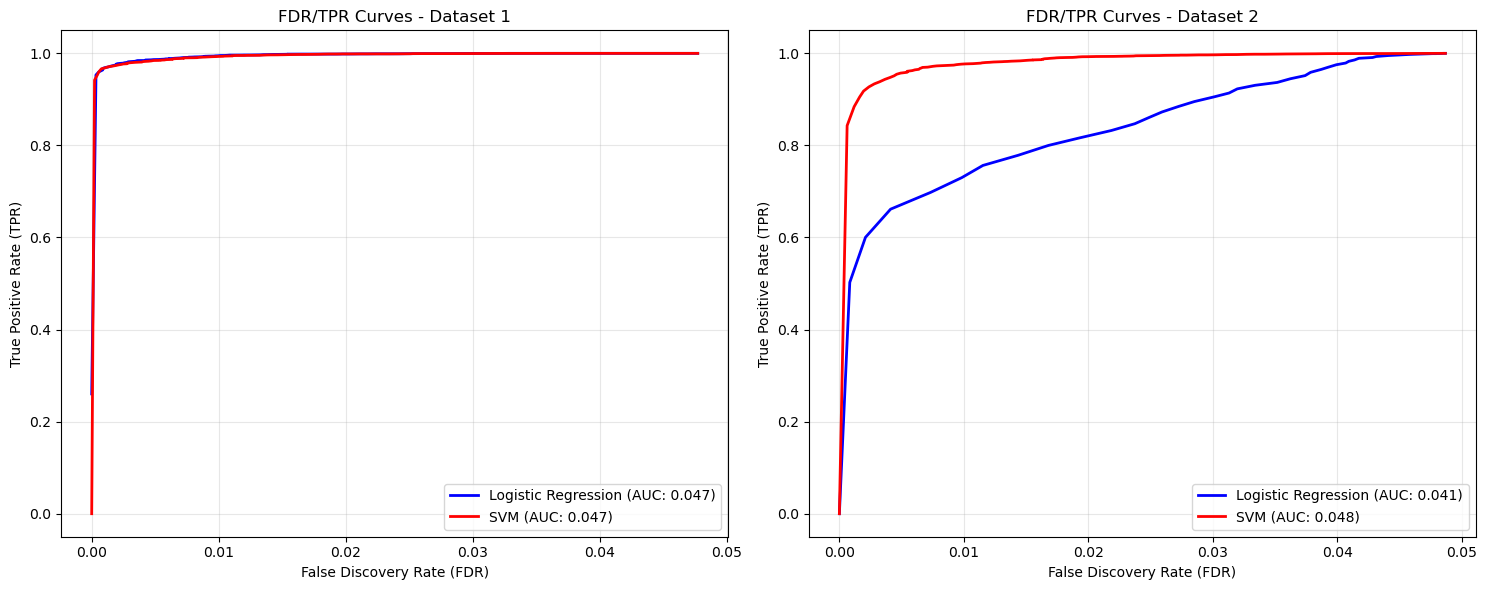

FDR/TPR AUC Results:
Dataset 1 - Logistic Regression: AUC = 0.0474
Dataset 1 - SVM: AUC = 0.0474
Dataset 2 - Logistic Regression: AUC = 0.0408
Dataset 2 - SVM: AUC = 0.0476


In [8]:
ths = np.linspace(0, 1, 100)

def calculate_fdr_tpr_auc(y_true, y_prob_pos, thresholds):

    positives = np.sum(y_true == 1)
    negatives = np.sum(y_true == 0)
    
    fdr_values = []
    tpr_values = []
    
    for threshold in thresholds:

        y_pred = (y_prob_pos >= threshold).astype(int)
        

        true_positives = np.sum((y_true == 1) & (y_pred == 1))
        false_positives = np.sum((y_true == 0) & (y_pred == 1))
        

        tpr = true_positives / positives if positives > 0 else 0
        
        predicted_positives = true_positives + false_positives
        fdr = false_positives / predicted_positives if predicted_positives > 0 else 0
        
        fdr_values.append(fdr)
        tpr_values.append(tpr)
    
    sorted_indices = np.argsort(fdr_values)
    fdr_sorted = np.array(fdr_values)[sorted_indices]
    tpr_sorted = np.array(tpr_values)[sorted_indices]
    

    auc = 0
    for i in range(len(fdr_sorted) - 1):
        auc += (tpr_sorted[i] + tpr_sorted[i+1]) / 2 * (fdr_sorted[i+1] - fdr_sorted[i])
    
    return fdr_values, tpr_values, auc

models_data = [
    ("Dataset 1 - Logistic Regression", y1_test, pred1_test[:, 1]),
    ("Dataset 1 - SVM", y1_test, svm1_pred_test[:, 1]),
    ("Dataset 2 - Logistic Regression", y2_test, pred2_test[:, 1]),
    ("Dataset 2 - SVM", y2_test, svm2_pred_test[:, 1])
]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax1 = axes[0]
colors1 = ['blue', 'red']
model_types1 = ['Logistic Regression', 'SVM']
for i, (name, y_true, y_prob) in enumerate(models_data[:2]):
    fdr, tpr, auc = calculate_fdr_tpr_auc(y_true, y_prob, ths)
    ax1.plot(fdr, tpr, color=colors1[i], label=f'{model_types1[i]} (AUC: {auc:.3f})', linewidth=2)

ax1.set_xlabel('False Discovery Rate (FDR)')
ax1.set_ylabel('True Positive Rate (TPR)')
ax1.set_title('FDR/TPR Curves - Dataset 1')
ax1.legend()
ax1.grid(True, alpha=0.3)


ax2 = axes[1]
colors2 = ['blue', 'red']
model_types2 = ['Logistic Regression', 'SVM']
for i, (name, y_true, y_prob) in enumerate(models_data[2:]):
    fdr, tpr, auc = calculate_fdr_tpr_auc(y_true, y_prob, ths)
    ax2.plot(fdr, tpr, color=colors2[i], label=f'{model_types2[i]} (AUC: {auc:.3f})', linewidth=2)

ax2.set_xlabel('False Discovery Rate (FDR)')
ax2.set_ylabel('True Positive Rate (TPR)')
ax2.set_title('FDR/TPR Curves - Dataset 2')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("FDR/TPR AUC Results:")
print("=" * 50)
for name, y_true, y_prob in models_data:
    fdr, tpr, auc = calculate_fdr_tpr_auc(y_true, y_prob, ths)
    print(f"{name}: AUC = {auc:.4f}")

For Dataset 1, both models perform almost identically: the FDR/TPR curves are overlapping and the AUC values are nearly the same.

For Dataset 2, the SVM clearly outperforms logistic regression. The SVM curve stays consistently above the logistic regression curve, and the AUC is higher. This indicates that the decision boundary in Dataset 2 is more complex, and the nonlinear kernel used by the SVM is better suited than the linear model. However, the logistic regression struggles to fit the data and achieves lower detection performance.

## 3) 
Let us now focus on the second dataset $(x_i, y^{(2)}_i)$, $i = 1, \ldots, m+n$. The goal is to find “good investment opportunities” in the test data set based on the features $x_i$, $i = m+1, \ldots, m+n$. We here assume that loans are either completely repaid with interest or fully delinquent. In reality, a lender tries to recover parts of delinquent loans.

We compare three different lending strategies:


i) We give out a loan to every person in the dataset in the amount of CHF 1000 charging an interest rate of $5.5\%$.

ii) We only charge an interest rate of $1\%$, but we selectively choose the applicants who are awarded a loan (in the amount of CHF 1000) using the selection criterion
$$
\hat{p}^{\log}_2(x_i) \ge 95\%.
$$
ii) We only charge an interest rate of $1\%$ but we selectively choose the applicants who are awarded a loan (in the amount of CHF 1000) using the selection criterion
$$
\hat{p}^{\mathrm{svm}}_2(\tilde{x}_i) \ge 95\%.
$$


In [ ]:
num_scenarios = 50000  
loan_amount = 1000    

print(f"Test data size: {n} borrowers")
print(f"Number of scenarios: {num_scenarios}")
print(f"Loan amount: CHF {loan_amount}")


print("\nGenerating market scenarios matrix D")


prob2_test = p2(X2_test) 


xi_scenarios = np.random.uniform(0, 1, (n, num_scenarios))


D = (xi_scenarios <= prob2_test.reshape(-1, 1)).astype(int)

print(f"Matrix D shape: {D.shape}")
print(f"Average repayment rate across all scenarios: {np.mean(D):.3f}")


prob_lr_test = pred2_test[:, 1]   
prob_svm_test = svm2_pred_test[:, 1]  

print(f"\nModel predictions summary:")
print(f"Logistic Regression - mean prob: {np.mean(prob_lr_test):.3f}")
print(f"SVM - mean prob: {np.mean(prob_svm_test):.3f}")
print(f"True p2 - mean prob: {np.mean(prob2_test):.3f}")


threshold = 0.95

# Strategy (i): Lend to everyone at 5.5% interest
strategy1_selected = np.ones(n, dtype=bool)  # Everyone gets a loan
interest_rate_1 = 0.055

# Strategy (ii): Selective lending at 1% using Logistic Regression
strategy2_selected = prob_lr_test >= threshold
interest_rate_2 = 0.01

# Strategy (iii): Selective lending at 1% using SVM
strategy3_selected = prob_svm_test >= threshold
interest_rate_3 = 0.01

print(f"\nStrategy selection results:")
print(f"Strategy 1 (5.5% to all): {np.sum(strategy1_selected)} loans ({100*np.mean(strategy1_selected):.1f}%)")
print(f"Strategy 2 (1% selective LR): {np.sum(strategy2_selected)} loans ({100*np.mean(strategy2_selected):.1f}%)")
print(f"Strategy 3 (1% selective SVM): {np.sum(strategy3_selected)} loans ({100*np.mean(strategy3_selected):.1f}%)")

Test data size: 10000 borrowers
Number of scenarios: 50000
Loan amount: CHF 1000

Generating market scenarios matrix D
Matrix D shape: (10000, 50000)
Average repayment rate across all scenarios: 0.950

Model predictions summary:
Logistic Regression - mean prob: 0.948
SVM - mean prob: 0.948
True p2 - mean prob: 0.950

Strategy selection results:
Strategy 1 (5.5% to all): 10000 loans (100.0%)
Strategy 2 (1% selective LR): 6992 loans (69.9%)
Strategy 3 (1% selective SVM): 8837 loans (88.4%)



Calculating profits and losses for each strategy

Profit/Loss Statistics:

Strategy 1 (5.5% to all):
  Expected Profit: CHF 22,360
  Standard Deviation: CHF 11,904
  Min Profit: CHF -27,085
  Max Profit: CHF 71,030
  5th Percentile: CHF 2,455
  95% VaR: CHF -2,455

Strategy 2 (1% LR selective):
  Expected Profit: CHF 4,875
  Standard Deviation: CHF 6,874
  Min Profit: CHF -23,000
  Max Profit: CHF 33,560
  5th Percentile: CHF -6,840
  95% VaR: CHF 6,840

Strategy 3 (1% SVM selective):
  Expected Profit: CHF 62,264
  Standard Deviation: CHF 4,715
  Min Profit: CHF 39,890
  Max Profit: CHF 79,280
  5th Percentile: CHF 54,030
  95% VaR: CHF -54,030


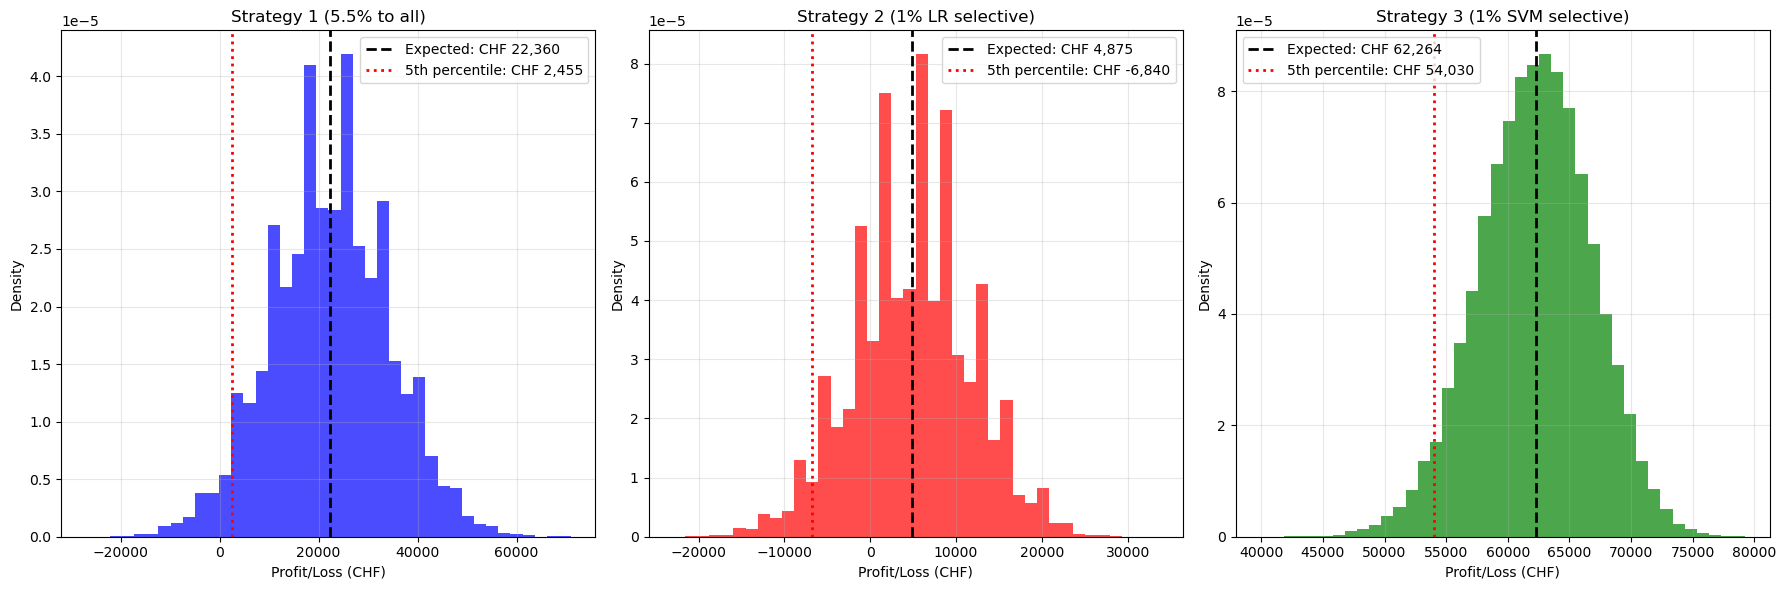

In [15]:
def calculate_strategy_performance(selected_borrowers, interest_rate, D_matrix, loan_amount):
    
    n_selected = np.sum(selected_borrowers)
    if n_selected == 0:
        return np.zeros(D_matrix.shape[1])
    

    D_selected = D_matrix[selected_borrowers, :]
    
    # For each scenario k:
    # Revenue = loan_amount * (1 + interest_rate) * number_of_repaid_loans[k]
    # Cost = loan_amount * total_loans_given
    # Profit = Revenue - Cost
    
    repaid_loans_per_scenario = np.sum(D_selected, axis=0)  # Sum over borrowers for each scenario
    
    revenue_per_scenario = loan_amount * (1 + interest_rate) * repaid_loans_per_scenario
    total_cost = loan_amount * n_selected
    
    profits_losses = revenue_per_scenario - total_cost
    
    return profits_losses

print("\nCalculating profits and losses for each strategy")

# Strategy 1: 5.5% interest to everyone
profits_strategy1 = calculate_strategy_performance(
    strategy1_selected, interest_rate_1, D, loan_amount
)

# Strategy 2: 1% interest to selected borrowers (Logistic Regression)
profits_strategy2 = calculate_strategy_performance(
    strategy2_selected, interest_rate_2, D, loan_amount
)

# Strategy 3: 1% interest to selected borrowers (SVM)
profits_strategy3 = calculate_strategy_performance(
    strategy3_selected, interest_rate_3, D, loan_amount
)


strategies = {
    'Strategy 1 (5.5% to all)': profits_strategy1,
    'Strategy 2 (1% LR selective)': profits_strategy2,
    'Strategy 3 (1% SVM selective)': profits_strategy3
}

print("\nProfit/Loss Statistics:")
for name, profits in strategies.items():
    expected_profit = np.mean(profits)
    std_profit = np.std(profits)
    min_profit = np.min(profits)
    max_profit = np.max(profits)
    percentile_5 = np.percentile(profits, 5)  # 5th percentile of profits
    var_95 = -percentile_5
    
    print(f"\n{name}:")
    print(f"  Expected Profit: CHF {expected_profit:,.0f}")
    print(f"  Standard Deviation: CHF {std_profit:,.0f}")
    print(f"  Min Profit: CHF {min_profit:,.0f}")
    print(f"  Max Profit: CHF {max_profit:,.0f}")
    print(f"  5th Percentile: CHF {percentile_5:,.0f}")
    print(f"  95% VaR: CHF {var_95:,.0f}")


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['blue', 'red', 'green']
strategy_names = list(strategies.keys())

for i, (name, profits) in enumerate(strategies.items()):
    ax = axes[i]
    ax.hist(profits, bins=40, alpha=0.7, color=colors[i], density=True)
    ax.axvline(np.mean(profits), color='black', linestyle='--', linewidth=2, 
               label=f'Expected: CHF {np.mean(profits):,.0f}')
    percentile_5 = np.percentile(profits, 5)
    ax.axvline(percentile_5, color='red', linestyle=':', linewidth=2,
               label=f'5th percentile: CHF {percentile_5:,.0f}')
    
    ax.set_xlabel('Profit/Loss (CHF)')
    ax.set_ylabel('Density')
    ax.set_title(f'{name}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



Risk-Return Analysis:
                     Strategy Expected Profit (CHF) Std Dev (CHF) VaR 95% (CHF) Sharpe Ratio Loans Issued
     Strategy 1 (5.5% to all)                22,360        11,904        -2,455        1.878       10,000
 Strategy 2 (1% LR selective)                 4,875         6,874         6,840        0.709        6,992
Strategy 3 (1% SVM selective)                62,264         4,715       -54,030       13.206        8,837


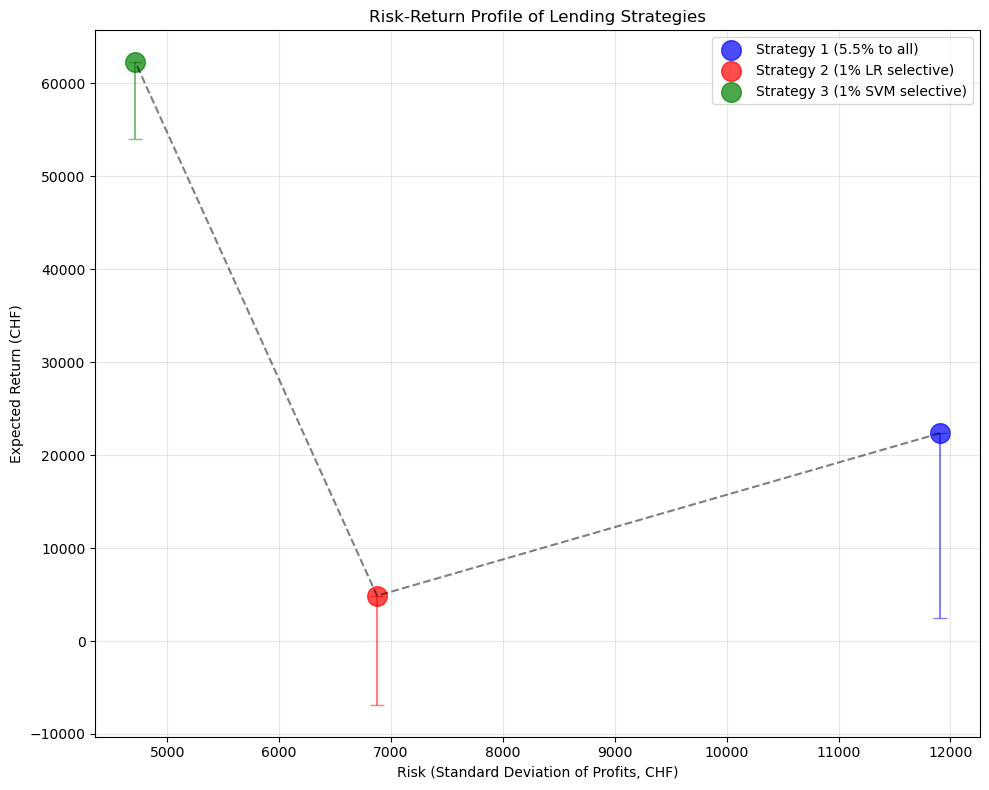

In [11]:

print("Risk-Return Analysis:")


summary_data = []
for name, profits in strategies.items():
    # Correctly determine which strategy is being processed
    if 'Strategy 1' in name:
        loans_issued = np.sum(strategy1_selected)
    elif 'Strategy 2' in name:
        loans_issued = np.sum(strategy2_selected)
    else:  # Strategy 3
        loans_issued = np.sum(strategy3_selected)
    
    summary_data.append({
        'Strategy': name,
        'Expected Profit (CHF)': f"{np.mean(profits):,.0f}",
        'Std Dev (CHF)': f"{np.std(profits):,.0f}",
        'VaR 95% (CHF)': f"{-np.percentile(profits, 5):,.0f}",
        'Sharpe Ratio': f"{np.mean(profits) / np.std(profits):.3f}",
        'Loans Issued': f"{loans_issued:,}"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Risk-Return scatter plot
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

for i, (name, profits) in enumerate(strategies.items()):
    expected_return = np.mean(profits)
    risk = np.std(profits)
    var_95 = -np.percentile(profits, 5)
    
    ax.scatter(risk, expected_return, s=200, color=colors[i], alpha=0.7, label=name)
    
    # Add VaR information as error bars
    ax.errorbar(risk, expected_return, yerr=[[expected_return - (-var_95)], [0]], 
                color=colors[i], alpha=0.5, capsize=5)

ax.set_xlabel('Risk (Standard Deviation of Profits, CHF)')
ax.set_ylabel('Expected Return (CHF)')
ax.set_title('Risk-Return Profile of Lending Strategies')
ax.legend()
ax.grid(True, alpha=0.3)

# Add efficient frontier line if helpful
risks = [np.std(profits) for profits in strategies.values()]
returns = [np.mean(profits) for profits in strategies.values()]

ax.plot(risks, returns, 'k--', alpha=0.5, label='Strategy comparison')
plt.tight_layout()
plt.show()